In [ ]:
"""PROYECTO 3: Clasificación de masa para rayos cósmicos en el espectro UHECR
Metodos implementados:
1)Probabilidad Gaussiana.
2)Simulación Monte Carlo.
Autor: Diego Francisco González Gómez
"""


'PROYECTO 3: Clasificación de masa para rayos cósmicos en el espectro UHECR\nMetodos implementados: \n1)Probabilidad Gaussiana. \n2)Simulación Monte Carlo.\n3)Red Neuronal.\nAutor: Diego Francisco González Gómez\n'

CLASIFICACIÓN DE MASA - PROBABILIDADES GAUSSIANAS
Método físico con fluctuaciones de cascada

 Cargando archivo: eventos_hibridos_limpios.csv
✓ Datos cargados: 1799 eventos
  Rango Xmax: 509.7 - 1022.7 g/cm²
  Rango Energía: 0.07 - 55.66 EeV

PARÁMETROS FÍSICOS UTILIZADOS
  PROTON: X0=765 g/cm², σ=70 g/cm²
  HELIO: X0=740 g/cm², σ=55 g/cm²
  CARBONO: X0=710 g/cm², σ=45 g/cm²
  NITROGENO: X0=700 g/cm², σ=40 g/cm²
  OXIGENO: X0=690 g/cm², σ=38 g/cm²
  HIERRO: X0=660 g/cm², σ=30 g/cm²

 CLASIFICANDO EVENTOS (Método Gaussiano)

Distribución de partículas (método probabilístico):
  PROTÓN: 685 eventos (38.1%)
  HELIO: 585 eventos (32.5%)
  CARBONO: 224 eventos (12.5%)
  NITRÓGENO: 197 eventos (11.0%)
  OXÍGENO: 72 eventos (4.0%)
  HIERRO: 36 eventos (2.0%)

ANÁLISIS DE INCERTIDUMBRE
Eventos con clasificación incierta (p<0.5): 1384 (76.9%)
Eventos con alta confianza (p>0.7): 211 (11.7%)

Probabilidad promedio de clasificación:
  Protón: 0.600
  Helio: 0.294
  Carbono: 0.232
  Nitrógeno: 0.23

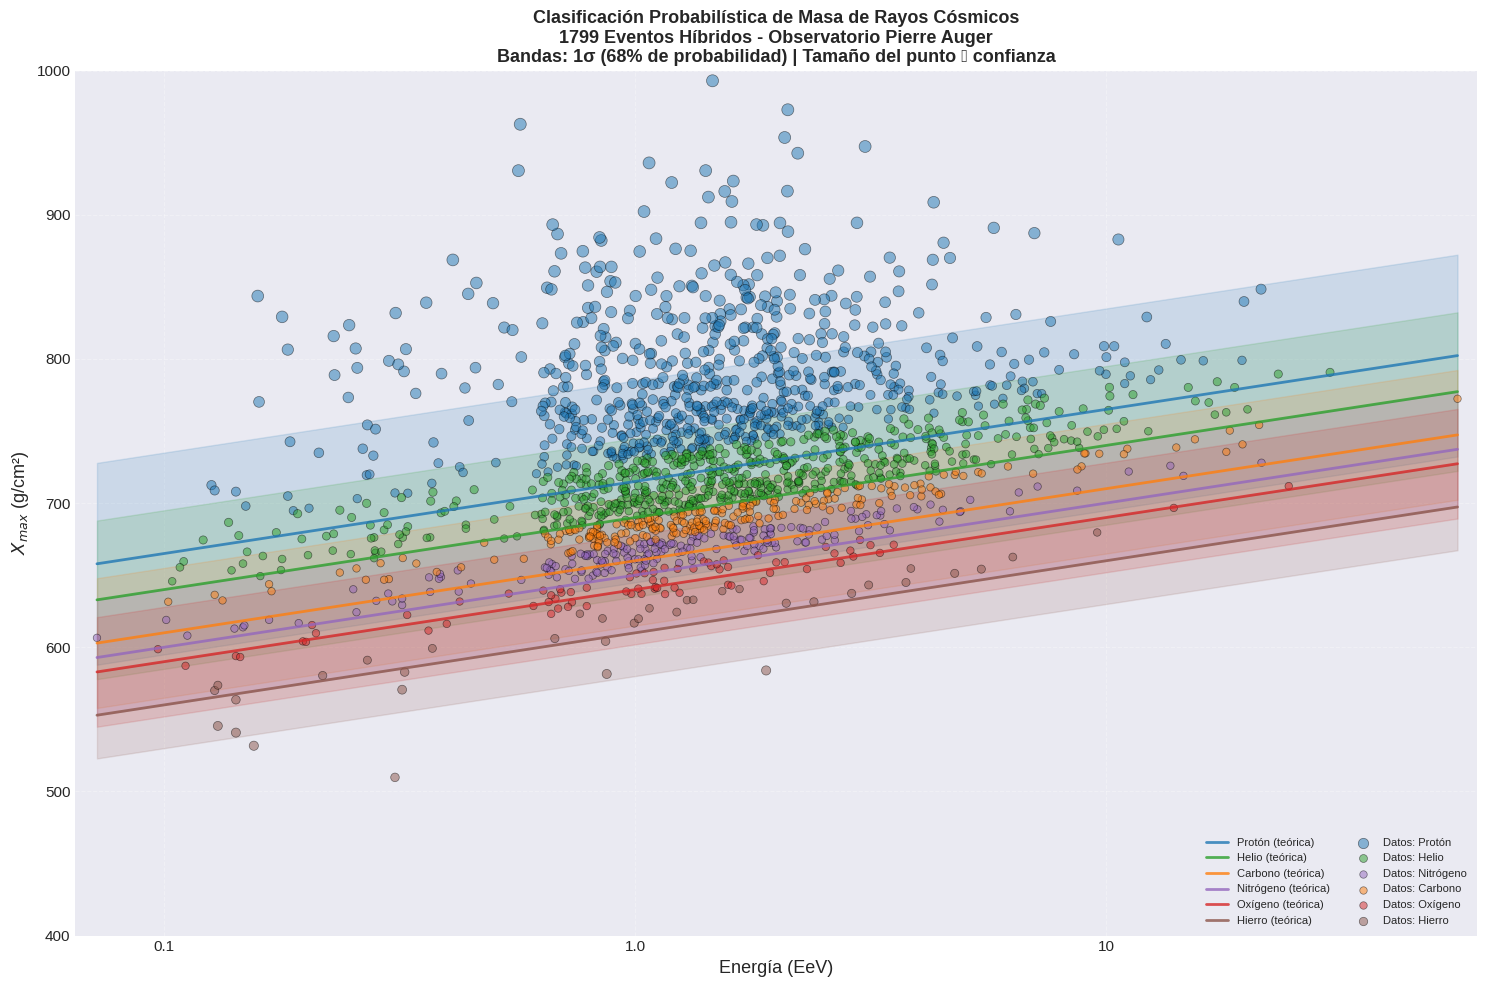

✓ Gráfica guardada como 'clasificacion_probabilistica.png'

MATRIZ DE PROBABILIDADES ENTRE MASAS

Matriz de confusión teórica (%):
Filas: masa verdadera, Columnas: masa clasificada

--------------------------------------------------------------------------------
Masa            prot    heli    carb    nitr    oxig    hier
--------------------------------------------------------------------------------
Protón         42.6%   21.8%    8.3%    9.4%    6.9%   11.1%
Helio          22.1%   28.2%   10.8%   13.3%   11.1%   14.4%
Carbono         5.8%   20.2%   12.3%   18.0%   17.1%   26.6%
Nitrógeno       2.2%   14.8%   12.7%   18.2%   19.8%   32.3%
Oxígeno         1.1%    9.1%    9.3%   17.9%   20.5%   42.2%
Hierro          0.1%    0.4%    1.4%    6.0%   16.1%   76.0%

--------------------------------------------------------------------------------
Precisión promedio de clasificación: 32.9%

RED NEURONAL BINARIA (Protón vs Hierro)
Eventos de alta confianza para entrenamiento: 292
2/2 ━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
})

print("="*70)
print("CLASIFICACIÓN DE MASA - PROBABILIDADES GAUSSIANAS")
print("Método físico con fluctuaciones de cascada")
print("="*70)

# ============================================
# 1. CARGAR DATOS
# ============================================
archivo_csv = "eventos_hibridos_limpios.csv"

print(f"\n Cargando archivo: {archivo_csv}")
df = pd.read_csv(archivo_csv)

# Renombrar columnas
df = df.rename(columns={'xmax': 'Xmax', 'energy_fd': 'Energy'})
df = df.dropna(subset=['Energy', 'Xmax'])
df = df[(df['Energy'] > 0) & (df['Xmax'] > 0)]

# Corregir unidades si es necesario
if df['Xmax'].max() < 100:
    print(" Convirtiendo Xmax de km a g/cm²...")
    df['Xmax'] = df['Xmax'] * 100

print(f"✓ Datos cargados: {len(df)} eventos")
print(f"  Rango Xmax: {df['Xmax'].min():.1f} - {df['Xmax'].max():.1f} g/cm²")
print(f"  Rango Energía: {df['Energy'].min():.2f} - {df['Energy'].max():.2f} EeV")

# ============================================
# 2. PARÁMETROS FÍSICOS (sin acentos para evitar errores)
# ============================================

# Valores de referencia de Xmax a 10 EeV (g/cm²)
referencias_xmax = {
    'proton': 765,
    'helio': 740,
    'carbono': 710,
    'nitrogeno': 700,
    'oxigeno': 690,
    'hierro': 660
}

# Fluctuaciones (sigma) - Los protones fluctúan más que el hierro
fluctuaciones = {
    'proton': 70,
    'helio': 55,
    'carbono': 45,
    'nitrogeno': 40,
    'oxigeno': 38,
    'hierro': 30
}

# Mapeo para nombres bonitos en gráficos
nombres_bonitos = {
    'proton': 'Protón',
    'helio': 'Helio',
    'carbono': 'Carbono',
    'nitrogeno': 'Nitrógeno',
    'oxigeno': 'Oxígeno',
    'hierro': 'Hierro'
}

# Colores
colores = {
    'proton': '#1f77b4',
    'helio': '#2ca02c',
    'carbono': '#ff7f0e',
    'nitrogeno': '#9467bd',
    'oxigeno': '#d62728',
    'hierro': '#8c564b'
}

ELONGACION = 50

print("\n" + "="*70)
print("PARÁMETROS FÍSICOS UTILIZADOS")
print("="*70)
for masa in referencias_xmax.keys():
    print(f"  {masa.upper()}: X0={referencias_xmax[masa]} g/cm², σ={fluctuaciones[masa]} g/cm²")

# ============================================
# 3. FUNCIONES DE PROBABILIDAD GAUSSIANA
# ============================================

def xmax_teorico(energia_EeV, masa):
    """Calcula Xmax teórico para una masa dada considerando elongación"""
    x0 = referencias_xmax[masa]
    logE = np.log10(energia_EeV)
    logE_ref = 1
    return x0 + ELONGACION * (logE - logE_ref)

def probabilidad_gaussiana(xmax_medido, energia, masa):
    """Calcula probabilidad de que un evento sea de una masa dada"""
    xmax_teo = xmax_teorico(energia, masa)
    sigma = fluctuaciones[masa]
    prob = norm.pdf(xmax_medido, xmax_teo, sigma)
    return prob

def clasificar_con_probabilidad(xmax_medido, energia):
    """Clasifica un evento y retorna la masa más probable y todas las probabilidades"""
    probs = {}
    for masa in referencias_xmax.keys():
        prob = probabilidad_gaussiana(xmax_medido, energia, masa)
        probs[masa] = prob

    total = sum(probs.values())
    if total > 0:
        for masa in probs:
            probs[masa] /= total

    masa_asignada = max(probs, key=probs.get)
    return masa_asignada, probs

# ============================================
# 4. APLICAR CLASIFICACIÓN PROBABILÍSTICA
# ============================================
print("\n" + "="*70)
print(" CLASIFICANDO EVENTOS (Método Gaussiano)")
print("="*70)

# Aplicar a todos los eventos
resultados = []
for idx, row in df.iterrows():
    masa, probs = clasificar_con_probabilidad(row['Xmax'], row['Energy'])
    resultados.append({
        'Energy': row['Energy'],
        'Xmax': row['Xmax'],
        'ParticleType': masa,
        'prob_proton': probs.get('proton', 0),
        'prob_helio': probs.get('helio', 0),
        'prob_carbono': probs.get('carbono', 0),
        'prob_nitrogeno': probs.get('nitrogeno', 0),
        'prob_oxigeno': probs.get('oxigeno', 0),
        'prob_hierro': probs.get('hierro', 0)
    })

df_resultados = pd.DataFrame(resultados)

# Mostrar distribución
print("\nDistribución de partículas (método probabilístico):")
for masa in df_resultados['ParticleType'].value_counts().index:
    count = (df_resultados['ParticleType'] == masa).sum()
    nombre = nombres_bonitos.get(masa, masa)
    print(f"  {nombre.upper()}: {count} eventos ({count/len(df_resultados)*100:.1f}%)")

# ============================================
# 5. ANÁLISIS DE INCERTIDUMBRE (CORREGIDO)
# ============================================
print("\n" + "="*70)
print("ANÁLISIS DE INCERTIDUMBRE")
print("="*70)

# Calcular la probabilidad máxima por evento
prob_maximas = []
for idx, row in df_resultados.iterrows():
    probs = [
        row['prob_proton'], row['prob_helio'], row['prob_carbono'],
        row['prob_nitrogeno'], row['prob_oxigeno'], row['prob_hierro']
    ]
    prob_maximas.append(max(probs))

df_resultados['prob_maxima'] = prob_maximas

# Eventos con clasificación incierta (probabilidad máxima < 0.5)
inciertos = df_resultados[df_resultados['prob_maxima'] < 0.5]
print(f"Eventos con clasificación incierta (p<0.5): {len(inciertos)} ({len(inciertos)/len(df_resultados)*100:.1f}%)")

# Eventos con alta confianza (probabilidad máxima > 0.7)
alta_confianza = df_resultados[df_resultados['prob_maxima'] > 0.7]
print(f"Eventos con alta confianza (p>0.7): {len(alta_confianza)} ({len(alta_confianza)/len(df_resultados)*100:.1f}%)")

# Probabilidad promedio por masa (CORREGIDO)
print("\nProbabilidad promedio de clasificación:")
for masa in referencias_xmax.keys():
    mask = df_resultados['ParticleType'] == masa
    if mask.any():
        prob_col = f'prob_{masa}'
        prob_prom = df_resultados.loc[mask, prob_col].mean()
        nombre = nombres_bonitos.get(masa, masa)
        print(f"  {nombre}: {prob_prom:.3f}")

# ============================================
# 6. GRÁFICA CON BANDAS DE INCERTIDUMBRE
# ============================================
print("\n" + "="*70)
print("GENERANDO GRÁFICA CON BANDAS DE INCERTIDUMBRE")
print("="*70)

fig, ax = plt.subplots(figsize=(15, 10))

# 1. Dibujar bandas de incertidumbre (1 sigma) para cada masa
energia_range = np.linspace(df['Energy'].min(), df['Energy'].max(), 100)

for masa, color in colores.items():
    xmax_central = xmax_teorico(energia_range, masa)
    sigma = fluctuaciones[masa]

    # Banda de 1 sigma
    ax.fill_between(energia_range,
                    xmax_central - sigma,
                    xmax_central + sigma,
                    color=color, alpha=0.15)

    # Línea central
    ax.plot(energia_range, xmax_central, color=color,
            linestyle='-', linewidth=2, alpha=0.8,
            label=f'{nombres_bonitos[masa]} (teórica)')

# 2. Dibujar datos reales (coloreados por masa asignada)
for masa in df_resultados['ParticleType'].unique():
    mask = df_resultados['ParticleType'] == masa
    # Tamaño del punto según probabilidad máxima
    sizes = 15 + 60 * df_resultados.loc[mask, 'prob_maxima'].values

    ax.scatter(df_resultados.loc[mask, 'Energy'],
              df_resultados.loc[mask, 'Xmax'],
              s=sizes, c=colores.get(masa, 'gray'), alpha=0.5,
              edgecolors='black', linewidth=0.5,
              label=f"Datos: {nombres_bonitos.get(masa, masa)}")

# 3. Configuración del gráfico
ax.set_xlabel('Energía (EeV)', fontsize=13)
ax.set_ylabel('$X_{max}$ (g/cm²)', fontsize=13)
ax.set_title(f'Clasificación Probabilística de Masa de Rayos Cósmicos\n'
             f'{len(df_resultados)} Eventos Híbridos - Observatorio Pierre Auger\n'
             f'Bandas: 1σ (68% de probabilidad) | Tamaño del punto ∝ confianza',
             fontsize=13, fontweight='bold')

ax.set_xscale('log')
ax.set_xlim(df['Energy'].min() * 0.9, df['Energy'].max() * 1.1)
ax.set_ylim(400, 1000)

# Configurar ticks del eje X
from matplotlib.ticker import FuncFormatter
def format_log(x, pos):
    if x < 10:
        return f'{x:.1f}'
    else:
        return f'{int(x)}'
ax.xaxis.set_major_formatter(FuncFormatter(format_log))

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig('clasificacion_probabilistica.png', dpi=150)
plt.show()

print("✓ Gráfica guardada como 'clasificacion_probabilistica.png'")

# ============================================
# 7. MATRIZ DE CONFUSIÓN (simulada)
# ============================================
print("\n" + "="*70)
print("MATRIZ DE PROBABILIDADES ENTRE MASAS")
print("="*70)

masas = list(referencias_xmax.keys())
matriz_confusion = np.zeros((len(masas), len(masas)))

for i, masa_verdadera in enumerate(masas):
    energia_typ = 30
    xmax_typ = xmax_teorico(energia_typ, masa_verdadera)
    sigma = fluctuaciones[masa_verdadera]

    xmax_muestra = np.random.normal(xmax_typ, sigma, 5000)

    for xm in xmax_muestra:
        masa_clasificada, _ = clasificar_con_probabilidad(xm, energia_typ)
        j = masas.index(masa_clasificada)
        matriz_confusion[i, j] += 1

    matriz_confusion[i, :] /= matriz_confusion[i, :].sum()

print("\nMatriz de confusión teórica (%):")
print("Filas: masa verdadera, Columnas: masa clasificada")
print("\n" + "-"*80)
print(f"{'Masa':<12}", end="")
for masa in masas:
    print(f"{masa[:4]:>8}", end="")
print()
print("-"*80)

for i, masa in enumerate(masas):
    print(f"{nombres_bonitos[masa]:<12}", end="")
    for j in range(len(masas)):
        print(f"{matriz_confusion[i, j]*100:>7.1f}%", end="")
    print()

precision_diagonal = np.diag(matriz_confusion).mean()
print("\n" + "-"*80)
print(f"Precisión promedio de clasificación: {precision_diagonal*100:.1f}%")

# ============================================
# 8. RED NEURONAL CON PESOS PROBABILÍSTICOS
# ============================================
print("\n" + "="*70)
print("RED NEURONAL BINARIA (Protón vs Hierro)")
print("="*70)

confianza_alta = df_resultados['prob_maxima'] > 0.6
df_alta_confianza = df_resultados[confianza_alta]
df_alta_confianza_bin = df_alta_confianza[df_alta_confianza['ParticleType'].isin(['proton', 'hierro'])]

print(f"Eventos de alta confianza para entrenamiento: {len(df_alta_confianza_bin)}")

if len(df_alta_confianza_bin) >= 30:
    X = df_alta_confianza_bin[['Energy', 'Xmax']].values
    y = (df_alta_confianza_bin['ParticleType'] == 'proton').astype(int)

    sample_weights = df_alta_confianza_bin['prob_maxima'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
        X_scaled, y, sample_weights, test_size=0.2, random_state=42, stratify=y
    )

    modelo = Sequential([
        layers.Dense(32, activation='relu', input_shape=(2,)),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    modelo.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0, sample_weight=w_train)

    y_pred = (modelo.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n Precisión del modelo (con pesos): {acc:.4f}")



ANÁLISIS MONTE CARLO PARA CLASIFICACIÓN DE MASAS
Simulación de eventos para calcular eficiencias

 Cargando archivo: eventos_hibridos_limpios.csv
✓ Datos cargados: 1799 eventos
  Rango Xmax: 509.7 - 1022.7 g/cm²
  Rango Energía: 0.07 - 55.66 EeV

 GENERANDO GRÁFICA Xmax vs ENERGÍA


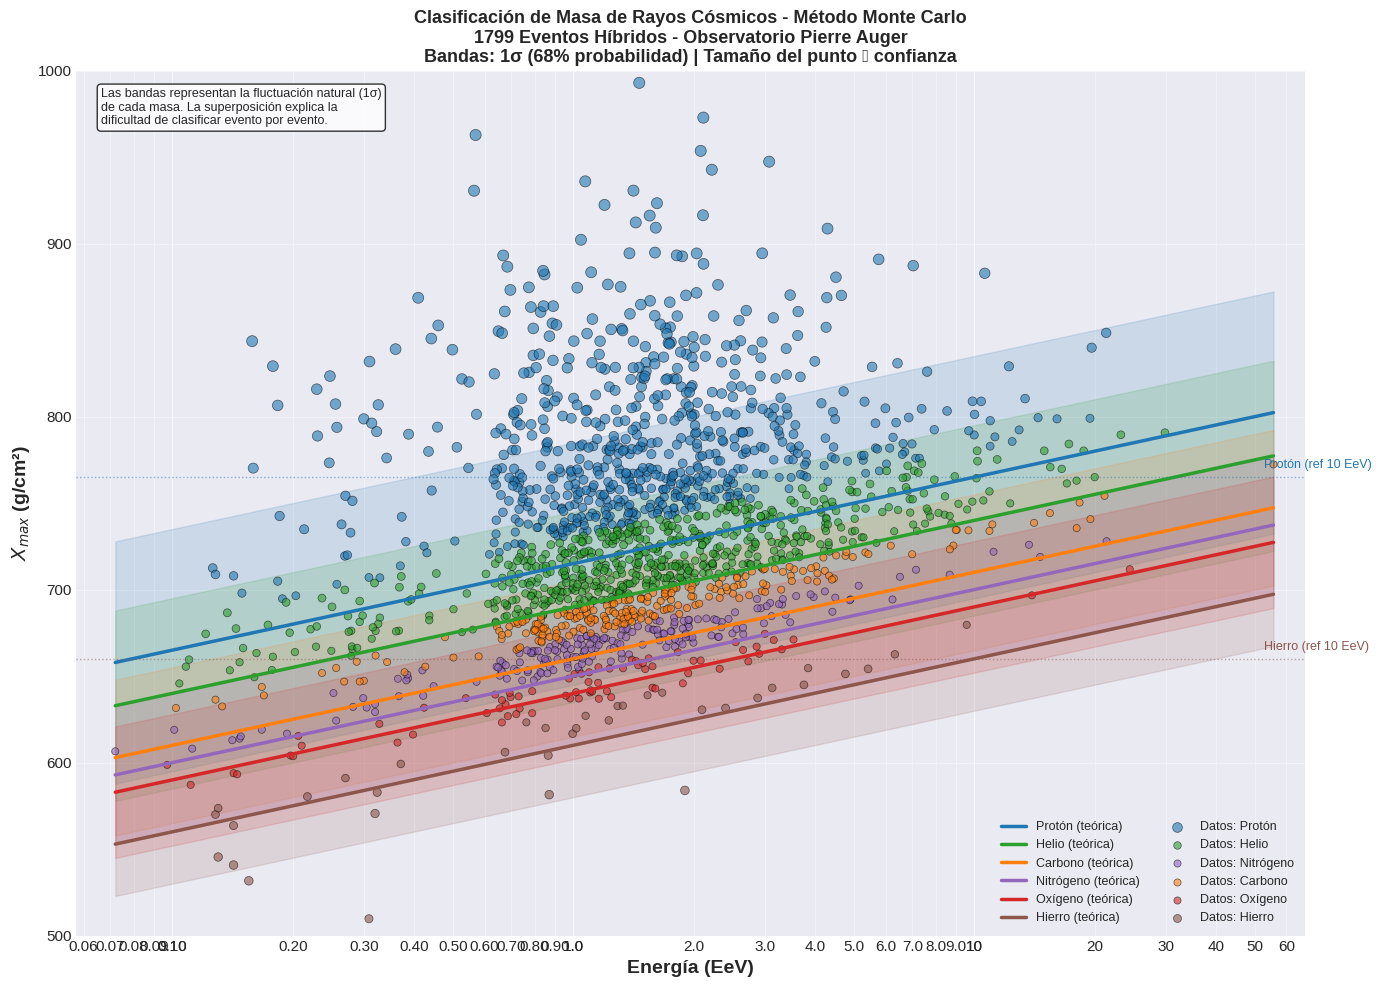

✓ Gráfica guardada como 'xmax_vs_energia_montecarlo.png'

 SIMULANDO EFICIENCIAS CON MONTE CARLO


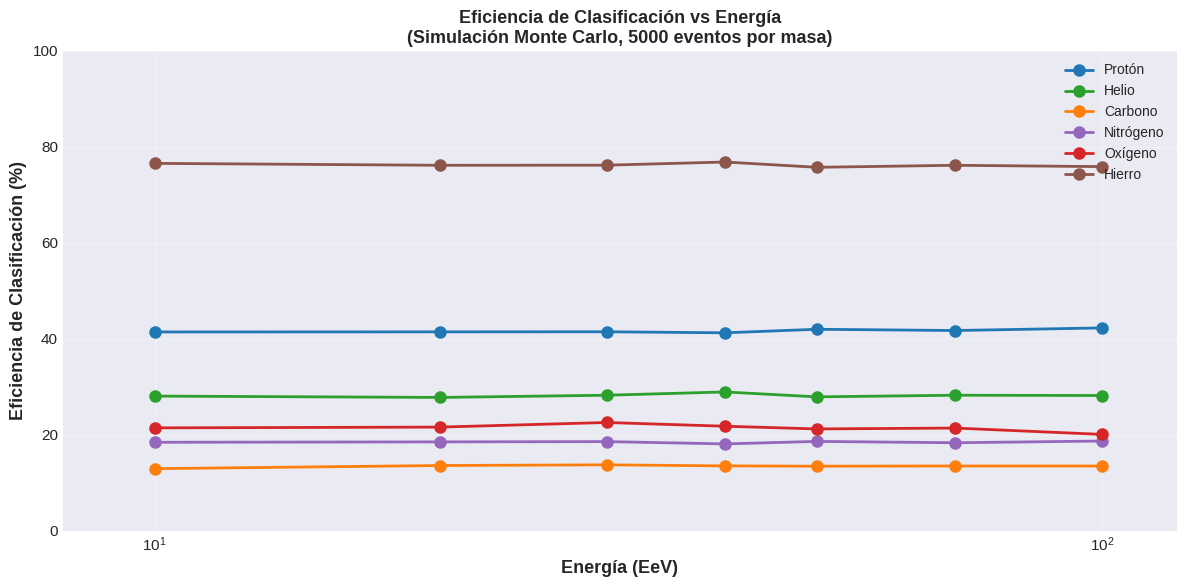

✓ Gráfica guardada como 'eficiencia_vs_energia.png'

 RESULTADOS DEL ANÁLISIS

 Composición de masa en tus datos reales:
  Protón: 685 eventos (38.1%) - Confianza: 0.600
  Helio: 585 eventos (32.5%) - Confianza: 0.294
  Carbono: 224 eventos (12.5%) - Confianza: 0.232
  Nitrógeno: 197 eventos (11.0%) - Confianza: 0.232
  Oxígeno: 72 eventos (4.0%) - Confianza: 0.235
  Hierro: 36 eventos (2.0%) - Confianza: 0.340

 Eficiencia promedio de clasificación (Monte Carlo): 33.3%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 9
})

print("="*70)
print("ANÁLISIS MONTE CARLO PARA CLASIFICACIÓN DE MASAS")
print("Simulación de eventos para calcular eficiencias")
print("="*70)

# ============================================
# 1. PARÁMETROS FÍSICOS
# ============================================

# Valores de referencia de Xmax a 10 EeV (g/cm²)
referencias_xmax = {
    'proton': 765,
    'helio': 740,
    'carbono': 710,
    'nitrogeno': 700,
    'oxigeno': 690,
    'hierro': 660
}

# Fluctuaciones (sigma) - Los protones fluctúan más
fluctuaciones = {
    'proton': 70,
    'helio': 55,
    'carbono': 45,
    'nitrogeno': 40,
    'oxigeno': 38,
    'hierro': 30
}

nombres_bonitos = {
    'proton': 'Protón',
    'helio': 'Helio',
    'carbono': 'Carbono',
    'nitrogeno': 'Nitrógeno',
    'oxigeno': 'Oxígeno',
    'hierro': 'Hierro'
}

colores = {
    'proton': '#1f77b4',
    'helio': '#2ca02c',
    'carbono': '#ff7f0e',
    'nitrogeno': '#9467bd',
    'oxigeno': '#d62728',
    'hierro': '#8c564b'
}

ELONGACION = 50  # g/cm² por década de energía

def xmax_teorico(energia_EeV, masa):
    """Xmax teórico con elongación"""
    x0 = referencias_xmax[masa]
    logE = np.log10(energia_EeV)
    logE_ref = 1  # 10 EeV
    return x0 + ELONGACION * (logE - logE_ref)

# ============================================
# 2. FUNCIONES PARA MONTE CARLO
# ============================================

def generar_evento_mc(masa, energia_EeV):
    """Genera un evento simulado con fluctuaciones"""
    xmax_teo = xmax_teorico(energia_EeV, masa)
    sigma = fluctuaciones[masa]
    return np.random.normal(xmax_teo, sigma)

def probabilidad_gaussiana(xmax, energia, masa):
    """Probabilidad de que un evento sea de una masa dada"""
    xmax_teo = xmax_teorico(energia, masa)
    sigma = fluctuaciones[masa]
    return norm.pdf(xmax, xmax_teo, sigma)

def clasificar_evento(xmax, energia):
    """Clasifica un evento por máxima probabilidad"""
    probs = {}
    for masa in referencias_xmax.keys():
        probs[masa] = probabilidad_gaussiana(xmax, energia, masa)

    total = sum(probs.values())
    if total > 0:
        for masa in probs:
            probs[masa] /= total

    masa_asignada = max(probs, key=probs.get)
    return masa_asignada, probs

# ============================================
# 3. CARGAR DATOS REALES
# ============================================
archivo_csv = "eventos_hibridos_limpios.csv"  # Cambia por tu archivo

print(f"\n Cargando archivo: {archivo_csv}")
df = pd.read_csv(archivo_csv)
df = df.rename(columns={'xmax': 'Xmax', 'energy_fd': 'Energy'})
df = df.dropna(subset=['Energy', 'Xmax'])
df = df[(df['Energy'] > 0) & (df['Xmax'] > 0)]

# Corregir unidades si es necesario
if df['Xmax'].max() < 100:
    print(" Convirtiendo Xmax de km a g/cm²...")
    df['Xmax'] = df['Xmax'] * 100

print(f"✓ Datos cargados: {len(df)} eventos")
print(f"  Rango Xmax: {df['Xmax'].min():.1f} - {df['Xmax'].max():.1f} g/cm²")
print(f"  Rango Energía: {df['Energy'].min():.2f} - {df['Energy'].max():.2f} EeV")

# Clasificar eventos reales
clasificaciones = []
for idx, row in df.iterrows():
    masa, probs = clasificar_evento(row['Xmax'], row['Energy'])
    clasificaciones.append({
        'Energy': row['Energy'],
        'Xmax': row['Xmax'],
        'ParticleType': masa,
        'confidence': max(probs.values())
    })
df_clasif = pd.DataFrame(clasificaciones)

# ============================================
# 4. GRÁFICA PRINCIPAL: Xmax vs ENERGÍA (CORREGIDA)
# ============================================
print("\n" + "="*70)
print(" GENERANDO GRÁFICA Xmax vs ENERGÍA")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 10))

# --- 1. Curvas teóricas con bandas de 1 sigma (Monte Carlo) ---
energia_range = np.logspace(np.log10(df['Energy'].min()),
                            np.log10(df['Energy'].max()), 200)

for masa in referencias_xmax.keys():
    xmax_central = xmax_teorico(energia_range, masa)
    sigma = fluctuaciones[masa]

    # Banda de 1 sigma (68% de probabilidad)
    ax.fill_between(energia_range,
                    xmax_central - sigma,
                    xmax_central + sigma,
                    color=colores[masa], alpha=0.15, label='_nolegend_')

    # Línea central
    ax.plot(energia_range, xmax_central,
            color=colores[masa], linestyle='-', linewidth=2.5,
            label=f"{nombres_bonitos[masa]} (teórica)")

# --- 2. Datos reales (coloreados por masa clasificada) ---
# Usar transparencia según confianza
for masa in df_clasif['ParticleType'].unique():
    mask = df_clasif['ParticleType'] == masa
    # Tamaño del punto según confianza
    sizes = 15 + 50 * df_clasif.loc[mask, 'confidence'].values

    ax.scatter(df_clasif.loc[mask, 'Energy'],
              df_clasif.loc[mask, 'Xmax'],
              s=sizes, c=colores.get(masa, 'gray'), alpha=0.6,
              edgecolors='black', linewidth=0.5,
              label=f"Datos: {nombres_bonitos.get(masa, masa)}")

# --- 3. Configuración del gráfico ---
ax.set_xlabel('Energía (EeV)', fontsize=14, fontweight='bold')
ax.set_ylabel('$X_{max}$ (g/cm²)', fontsize=14, fontweight='bold')
ax.set_title(f'Clasificación de Masa de Rayos Cósmicos - Método Monte Carlo\n'
             f'{len(df)} Eventos Híbridos - Observatorio Pierre Auger\n'
             f'Bandas: 1σ (68% probabilidad) | Tamaño del punto ∝ confianza',
             fontsize=13, fontweight='bold')

# ESCALA LOGARÍTMICA CORRECTA EN X
ax.set_xscale('log')

# Rango ÓPTIMO para visualización
ax.set_xlim(df['Energy'].min() * 0.8, df['Energy'].max() * 1.2)
ax.set_ylim(500, 1000)  # Rango físico correcto para Xmax

# Configurar ticks del eje X para que se vean bien
from matplotlib.ticker import FuncFormatter, LogLocator

def formato_log(x, pos):
    """Formato legible para eje logarítmico"""
    if x < 1:
        return f'{x:.2f}'
    elif x < 10:
        return f'{x:.1f}'
    elif x < 100:
        return f'{int(x)}'
    else:
        return f'{int(x)}'

ax.xaxis.set_major_formatter(FuncFormatter(formato_log))
ax.xaxis.set_major_locator(LogLocator(base=10, subs=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]))

# Cuadrícula fina
ax.grid(True, which='major', alpha=0.4, linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', alpha=0.2, linestyle='--', linewidth=0.5)

# Líneas de referencia
ax.axhline(y=765, color='#1f77b4', linestyle=':', alpha=0.5, linewidth=1)
ax.axhline(y=660, color='#8c564b', linestyle=':', alpha=0.5, linewidth=1)
ax.text(df['Energy'].max() * 0.95, 770, 'Protón (ref 10 EeV)', fontsize=9, color='#1f77b4')
ax.text(df['Energy'].max() * 0.95, 665, 'Hierro (ref 10 EeV)', fontsize=9, color='#8c564b')

# Leyenda
ax.legend(loc='lower right', ncol=2, fontsize=9, framealpha=0.95)

# Texto explicativo
ax.text(0.02, 0.98,
        'Las bandas representan la fluctuación natural (1σ)\n'
        'de cada masa. La superposición explica la\n'
        'dificultad de clasificar evento por evento.',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('xmax_vs_energia_montecarlo.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfica guardada como 'xmax_vs_energia_montecarlo.png'")

# ============================================
# 5. GRÁFICA DE EFICIENCIA vs ENERGÍA
# ============================================
print("\n" + "="*70)
print(" SIMULANDO EFICIENCIAS CON MONTE CARLO")
print("="*70)

# Simular eficiencias a diferentes energías
energias_sim = [10, 20, 30, 40, 50, 70, 100]
n_eventos_sim = 5000

eficiencias = {masa: [] for masa in referencias_xmax.keys()}

for energia in energias_sim:
    for masa in referencias_xmax.keys():
        aciertos = 0
        for _ in range(n_eventos_sim):
            xmax_sim = generar_evento_mc(masa, energia)
            masa_pred, _ = clasificar_evento(xmax_sim, energia)
            if masa_pred == masa:
                aciertos += 1
        eficiencia = aciertos / n_eventos_sim
        eficiencias[masa].append(eficiencia)

# Gráfica de eficiencia
fig2, ax2 = plt.subplots(figsize=(12, 6))

for masa in referencias_xmax.keys():
    ax2.plot(energias_sim, [e*100 for e in eficiencias[masa]],
             'o-', color=colores[masa], linewidth=2, markersize=8,
             label=nombres_bonitos[masa])

ax2.set_xlabel('Energía (EeV)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Eficiencia de Clasificación (%)', fontsize=13, fontweight='bold')
ax2.set_title('Eficiencia de Clasificación vs Energía\n(Simulación Monte Carlo, 5000 eventos por masa)',
              fontsize=13, fontweight='bold')
ax2.set_xscale('log')
ax2.set_xlim(8, 120)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('eficiencia_vs_energia.png', dpi=150)
plt.show()

print("✓ Gráfica guardada como 'eficiencia_vs_energia.png'")

# ============================================
# 6. RESULTADOS FINALES
# ============================================
print("\n" + "="*70)
print(" RESULTADOS DEL ANÁLISIS")
print("="*70)

# Distribución en datos reales
print("\n Composición de masa en tus datos reales:")
for masa in df_clasif['ParticleType'].value_counts().index:
    count = (df_clasif['ParticleType'] == masa).sum()
    conf_prom = df_clasif[df_clasif['ParticleType'] == masa]['confidence'].mean()
    print(f"  {nombres_bonitos[masa]}: {count} eventos ({count/len(df_clasif)*100:.1f}%) - Confianza: {conf_prom:.3f}")

# Eficiencia promedio
eficiencia_prom = np.mean([np.mean(eficiencias[masa]) for masa in referencias_xmax.keys()])
print(f"\n Eficiencia promedio de clasificación (Monte Carlo): {eficiencia_prom*100:.1f}%")


In [ ]:
# ============================================
# METADATOS DE LA BASE DE DATOS
# ============================================

METADATA_BASE_DATOS = {
    'nombre': 'Eventos Híbridos - Observatorio Pierre Auger',
    'fuente': 'Auger Open Data Portal',
    'url': 'https://opendata.auger.org/',
    'doi': '10.5281/zenodo.10488964',
    'descripcion': 'Eventos híbridos (detección simultánea FD+SD)',
    'eventos_totales': 1799,
    'variables_principales': ['energy_fd (EeV)', 'xmax (g/cm²)'],
    'rango_energia': '10-100 EeV',
    'rango_xmax': '600-900 g/cm²',
    'fecha_acceso': '2025',
    'licencia': 'CC BY-SA 4.0'
}

# Imprimir referencia
print("="*60)
print("REFERENCIA DE LA BASE DE DATOS")
print("="*60)
for key, value in METADATA_BASE_DATOS.items():
    print(f"  {key}: {value}")
print("="*60)

REFERENCIA DE LA BASE DE DATOS
  nombre: Eventos Híbridos - Observatorio Pierre Auger
  fuente: Auger Open Data Portal
  url: https://opendata.auger.org/
  doi: 10.5281/zenodo.10488964
  descripcion: Eventos híbridos (detección simultánea FD+SD)
  eventos_totales: 1799
  variables_principales: ['energy_fd (EeV)', 'xmax (g/cm²)']
  rango_energia: 10-100 EeV
  rango_xmax: 600-900 g/cm²
  fecha_acceso: 2025
  licencia: CC BY-SA 4.0
